# Financial Data Analysis: Microsoft, Tesla, and Apple (FY2023–FY2025)
### BCG GenAI Consulting Job Simulation — Task 2

**Objective:** Analyze key financial metrics extracted from the 10-K filings of Microsoft, Tesla, and Apple
for fiscal years 2023–2025, in order to identify trends and insights that could inform the development
of an AI-powered financial chatbot.

**Methodology:** Financial figures (Total Revenue, Net Income, Total Assets, Total Liabilities, and
Cash Flow from Operating Activities) were manually extracted from each company's Form 10-K, sourced from
the SEC's EDGAR database (sec.gov/edgar). Data was compiled into an Excel spreadsheet and exported as a
CSV file for analysis in this notebook using pandas.

**A note on fiscal years:** The three companies do not share a common fiscal year-end, which is important
context for a chatbot that will compare them:
- **Microsoft**: fiscal year ends June 30 (FY2025 = July 2024–June 2025)
- **Apple**: fiscal year ends on the last Saturday of September (FY2025 ended September 27, 2025)
- **Tesla**: fiscal year ends December 31 (a calendar year)


## Step 1: Import Libraries and Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Display settings
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('default')


In [2]:
# Load the extracted financial data (converted from the Excel spreadsheet to CSV)
df = pd.read_csv('financial_data_2023_2025.csv')
df


,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operations
0,Microsoft,2023,211915,72361,411976,205753,87582
1,Microsoft,2024,245122,88136,512163,243686,118548
2,Microsoft,2025,281724,101832,619003,275524,136162
3,Apple,2023,383285,96995,352583,290437,110543
4,Apple,2024,391035,93736,364980,308030,118254
5,Apple,2025,416161,112010,359241,285511,111482
6,Tesla,2023,96773,14997,106618,43009,13256
7,Tesla,2024,97690,7091,122070,48390,14923
8,Tesla,2025,94827,3794,137806,54941,14747


In [3]:
# Basic info about the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Company                    9 non-null      str  
 1   Fiscal Year                9 non-null      int64
 2   Total Revenue              9 non-null      int64
 3   Net Income                 9 non-null      int64
 4   Total Assets               9 non-null      int64
 5   Total Liabilities          9 non-null      int64
 6   Cash Flow from Operations  9 non-null      int64
dtypes: int64(6), str(1)
memory usage: 636.0 bytes


## Step 2: Analyzing Trends with Pandas

We calculate year-over-year (YoY) percentage changes for each key financial metric, grouped by company.
This lets us see how each company's revenue, profitability, and balance sheet evolved from FY2023 to FY2025.


In [4]:
# Sort to make sure growth calculations follow chronological order within each company
df = df.sort_values(['Company', 'Fiscal Year']).reset_index(drop=True)

# Year-over-year growth rates (%)
df['Revenue Growth (%)'] = df.groupby('Company')['Total Revenue'].pct_change() * 100
df['Net Income Growth (%)'] = df.groupby('Company')['Net Income'].pct_change() * 100
df['Total Assets Growth (%)'] = df.groupby('Company')['Total Assets'].pct_change() * 100
df['Total Liabilities Growth (%)'] = df.groupby('Company')['Total Liabilities'].pct_change() * 100
df['CFO Growth (%)'] = df.groupby('Company')['Cash Flow from Operations'].pct_change() * 100

df.round(2)


,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operations,Revenue Growth (%),Net Income Growth (%),Total Assets Growth (%),Total Liabilities Growth (%),CFO Growth (%)
0,Apple,2023,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN
1,Apple,2024,391035,93736,364980,308030,118254,2.02,-3.36,3.52,6.06,6.98
2,Apple,2025,416161,112010,359241,285511,111482,6.43,19.50,-1.57,-7.31,-5.73
3,Microsoft,2023,211915,72361,411976,205753,87582,NaN,NaN,NaN,NaN,NaN
4,Microsoft,2024,245122,88136,512163,243686,118548,15.67,21.80,24.32,18.44,35.36
5,Microsoft,2025,281724,101832,619003,275524,136162,14.93,15.54,20.86,13.07,14.86
6,Tesla,2023,96773,14997,106618,43009,13256,NaN,NaN,NaN,NaN,NaN
7,Tesla,2024,97690,7091,122070,48390,14923,0.95,-52.72,14.49,12.51,12.58
8,Tesla,2025,94827,3794,137806,54941,14747,-2.93,-46.50,12.89,13.54,-1.18


### Additional derived metrics

Beyond simple growth rates, a financial chatbot would likely need ratio-based metrics that put raw
numbers into context — for example, profitability margins and balance sheet leverage.


In [5]:
# Net Profit Margin = Net Income / Total Revenue
df['Net Profit Margin (%)'] = (df['Net Income'] / df['Total Revenue']) * 100

# Debt-to-Assets Ratio = Total Liabilities / Total Assets  (a simple leverage indicator)
df['Debt-to-Assets Ratio'] = df['Total Liabilities'] / df['Total Assets']

# Cash Flow to Net Income Ratio (a simple "earnings quality" indicator; >1 suggests
# earnings are well backed by actual cash generation)
df['CFO to Net Income Ratio'] = df['Cash Flow from Operations'] / df['Net Income']

df.round(2)


,Company,Fiscal Year,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operations,Revenue Growth (%),Net Income Growth (%),Total Assets Growth (%),Total Liabilities Growth (%),CFO Growth (%),Net Profit Margin (%),Debt-to-Assets Ratio,CFO to Net Income Ratio
0,Apple,2023,383285,96995,352583,290437,110543,NaN,NaN,NaN,NaN,NaN,25.31,0.82,1.14
1,Apple,2024,391035,93736,364980,308030,118254,2.02,-3.36,3.52,6.06,6.98,23.97,0.84,1.26
2,Apple,2025,416161,112010,359241,285511,111482,6.43,19.50,-1.57,-7.31,-5.73,26.92,0.79,1.00
3,Microsoft,2023,211915,72361,411976,205753,87582,NaN,NaN,NaN,NaN,NaN,34.15,0.50,1.21
4,Microsoft,2024,245122,88136,512163,243686,118548,15.67,21.80,24.32,18.44,35.36,35.96,0.48,1.35
5,Microsoft,2025,281724,101832,619003,275524,136162,14.93,15.54,20.86,13.07,14.86,36.15,0.45,1.34
6,Tesla,2023,96773,14997,106618,43009,13256,NaN,NaN,NaN,NaN,NaN,15.50,0.40,0.88
7,Tesla,2024,97690,7091,122070,48390,14923,0.95,-52.72,14.49,12.51,12.58,7.26,0.40,2.10
8,Tesla,2025,94827,3794,137806,54941,14747,-2.93,-46.50,12.89,13.54,-1.18,4.00,0.40,3.89


## Step 3: Exploring Other Aggregations

Let's look at the data from a few other angles: company-level averages across the 3-year window, and
which company leads on each metric in the most recent fiscal year (2025).


In [6]:
# Average metrics per company across FY2023-2025
company_avg = df.groupby('Company')[['Total Revenue', 'Net Income', 'Total Assets',
                                       'Total Liabilities', 'Cash Flow from Operations',
                                       'Net Profit Margin (%)', 'Debt-to-Assets Ratio']].mean()
company_avg.round(2)


,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operations,Net Profit Margin (%),Debt-to-Assets Ratio
Company,,,,,,,
Apple,"396,827.00","100,913.67","358,934.67","294,659.33","113,426.33",25.40,0.82
Microsoft,"246,253.67","87,443.00","514,380.67","241,654.33","114,097.33",35.42,0.47
Tesla,"96,430.00","8,627.33","122,164.67","48,780.00","14,308.67",8.92,0.40


In [7]:
# Compound Annual Growth Rate (CAGR) from FY2023 to FY2025 for each metric
def cagr(first, last, periods=2):
    return ((last / first) ** (1 / periods) - 1) * 100

cagr_rows = []
for company in df['Company'].unique():
    sub = df[df['Company'] == company].sort_values('Fiscal Year')
    first, last = sub.iloc[0], sub.iloc[-1]
    cagr_rows.append({
        'Company': company,
        'Revenue CAGR (%)': cagr(first['Total Revenue'], last['Total Revenue']),
        'Net Income CAGR (%)': cagr(first['Net Income'], last['Net Income']),
        'Total Assets CAGR (%)': cagr(first['Total Assets'], last['Total Assets']),
        'CFO CAGR (%)': cagr(first['Cash Flow from Operations'], last['Cash Flow from Operations']),
    })

cagr_df = pd.DataFrame(cagr_rows).set_index('Company')
cagr_df.round(2)


,Revenue CAGR (%),Net Income CAGR (%),Total Assets CAGR (%),CFO CAGR (%)
Company,,,,
Apple,4.20,7.46,0.94,0.42
Microsoft,15.30,18.63,22.58,24.69
Tesla,-1.01,-49.70,13.69,5.47


In [8]:
# 2025 snapshot: who leads on each metric?
snapshot_2025 = df[df['Fiscal Year'] == 2025].set_index('Company')[
    ['Total Revenue', 'Net Income', 'Total Assets', 'Total Liabilities',
     'Cash Flow from Operations', 'Net Profit Margin (%)', 'Debt-to-Assets Ratio']
]
snapshot_2025.round(2)


,Total Revenue,Net Income,Total Assets,Total Liabilities,Cash Flow from Operations,Net Profit Margin (%),Debt-to-Assets Ratio
Company,,,,,,,
Apple,416161,112010,359241,285511,111482,26.92,0.79
Microsoft,281724,101832,619003,275524,136162,36.15,0.45
Tesla,94827,3794,137806,54941,14747,4.00,0.40


## Step 4: Visualizing the Trends

Charts make it much easier to spot trends at a glance than tables of numbers — useful both for
our own analysis and as a preview of the kind of visual summaries a chatbot interface might generate
on request.


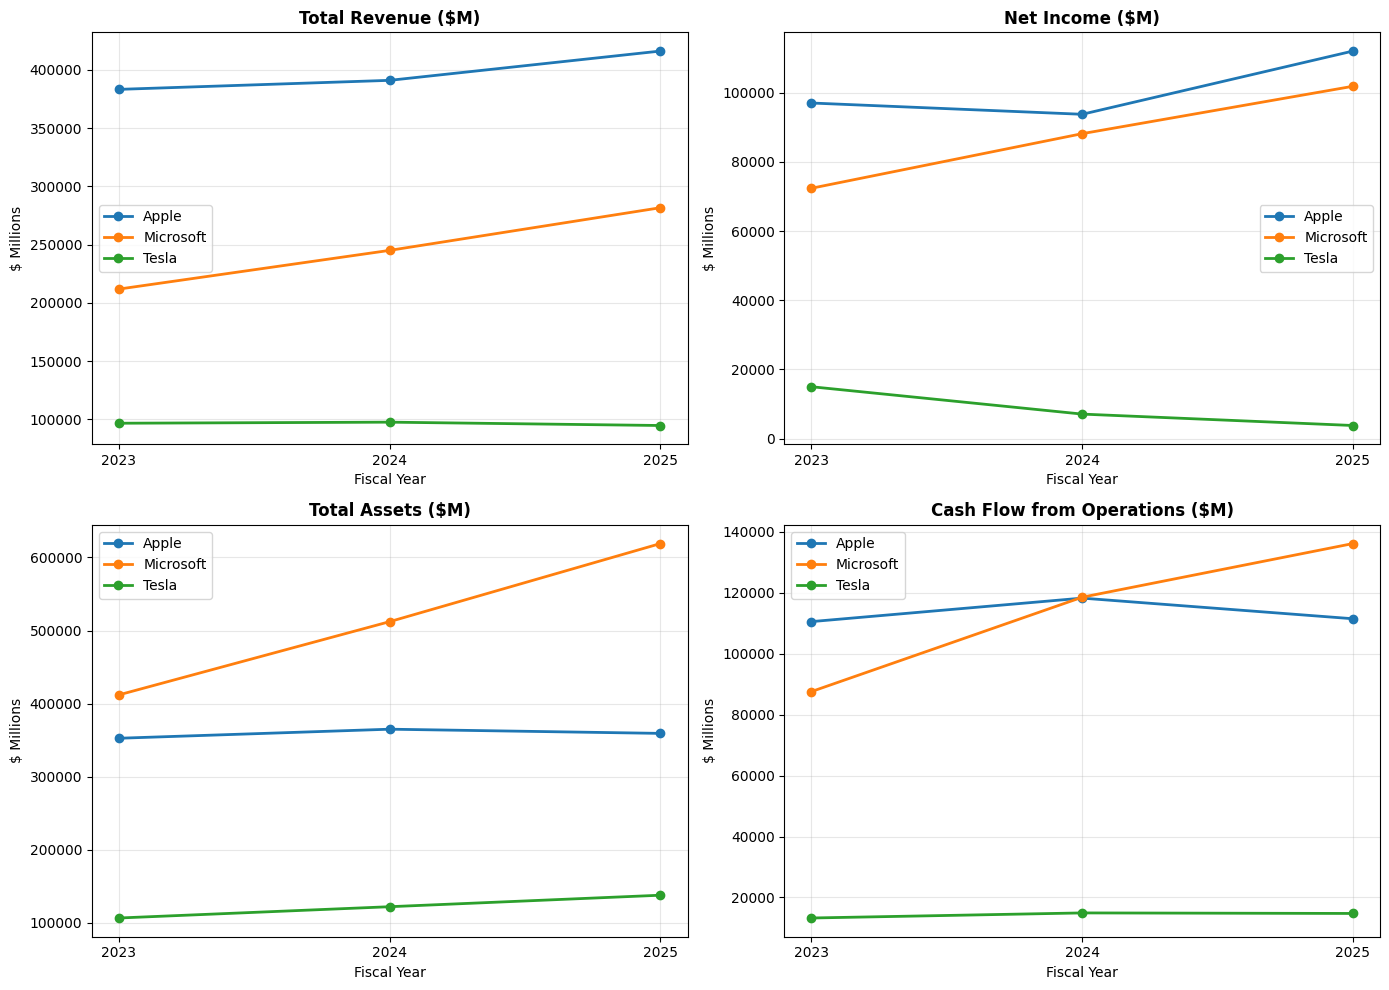

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ('Total Revenue', axes[0, 0], 'Total Revenue ($M)'),
    ('Net Income', axes[0, 1], 'Net Income ($M)'),
    ('Total Assets', axes[1, 0], 'Total Assets ($M)'),
    ('Cash Flow from Operations', axes[1, 1], 'Cash Flow from Operations ($M)'),
]

for metric, ax, title in metrics:
    for company in df['Company'].unique():
        sub = df[df['Company'] == company].sort_values('Fiscal Year')
        ax.plot(sub['Fiscal Year'], sub[metric], marker='o', label=company, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Fiscal Year')
    ax.set_ylabel('$ Millions')
    ax.set_xticks([2023, 2024, 2025])
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('key_metrics_trends.png', dpi=120)
plt.show()


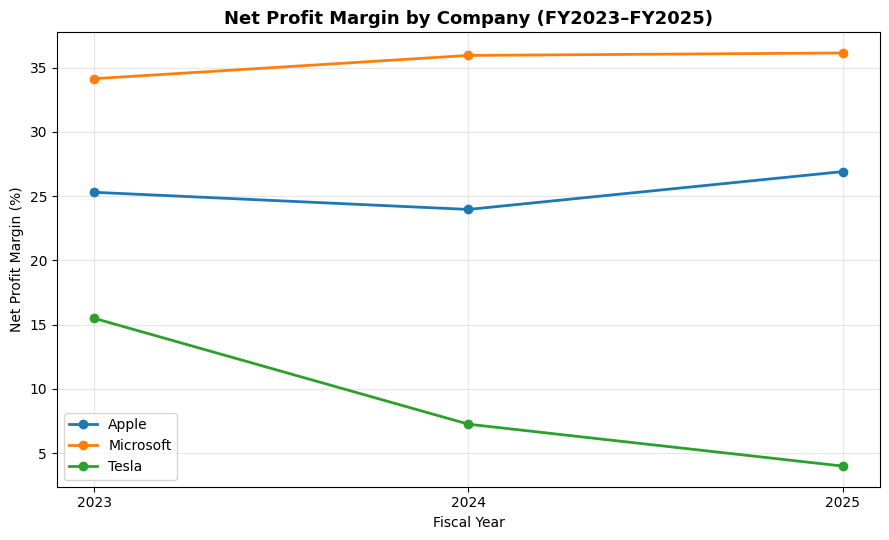

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for company in df['Company'].unique():
    sub = df[df['Company'] == company].sort_values('Fiscal Year')
    ax.plot(sub['Fiscal Year'], sub['Net Profit Margin (%)'], marker='o', linewidth=2, label=company)

ax.set_title('Net Profit Margin by Company (FY2023–FY2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Net Profit Margin (%)')
ax.set_xticks([2023, 2024, 2025])
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('profit_margin_trends.png', dpi=120)
plt.show()


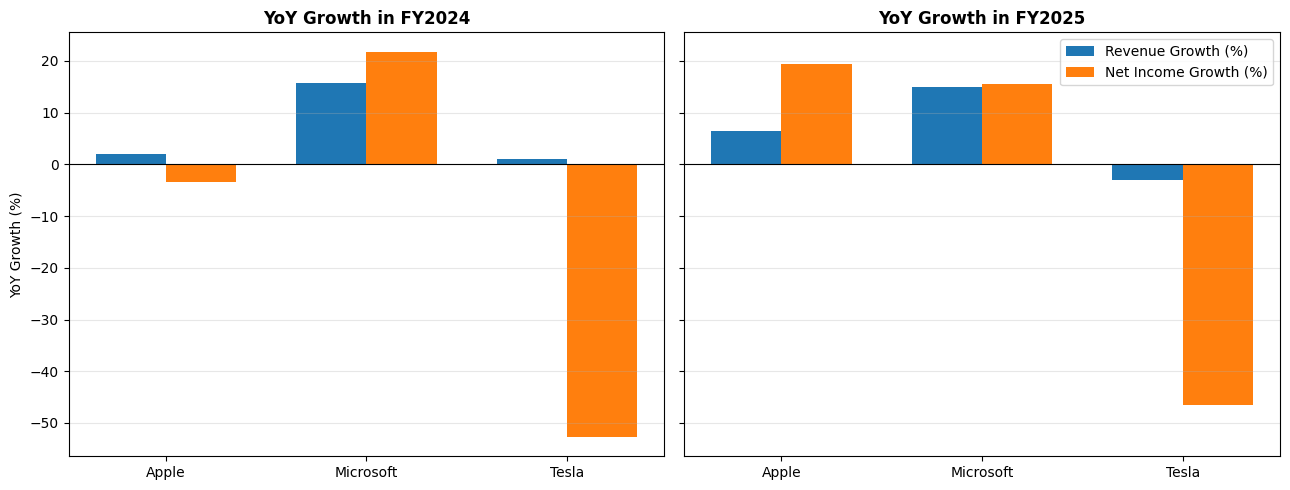

In [11]:
# Revenue vs. Net Income growth (YoY) side-by-side, by company
growth_2024 = df[df['Fiscal Year'] == 2024][['Company', 'Revenue Growth (%)', 'Net Income Growth (%)']]
growth_2025 = df[df['Fiscal Year'] == 2025][['Company', 'Revenue Growth (%)', 'Net Income Growth (%)']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, growth_df, year in zip(axes, [growth_2024, growth_2025], [2024, 2025]):
    x = np.arange(len(growth_df))
    width = 0.35
    ax.bar(x - width/2, growth_df['Revenue Growth (%)'], width, label='Revenue Growth (%)')
    ax.bar(x + width/2, growth_df['Net Income Growth (%)'], width, label='Net Income Growth (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(growth_df['Company'])
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'YoY Growth in FY{year}', fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

axes[0].set_ylabel('YoY Growth (%)')
axes[1].legend()
plt.tight_layout()
plt.savefig('yoy_growth_comparison.png', dpi=120)
plt.show()


## Step 5: Implications for an AI-Powered Financial Chatbot

The exercise of manually extracting and structuring this data highlights a few practical considerations
for designing a chatbot that answers financial questions about companies like these:

1. **Fiscal year misalignment matters.** Microsoft, Apple, and Tesla report on different fiscal calendars.
   A chatbot comparing "2025 revenue" across companies must be explicit about which fiscal year it means,
   or it risks comparing periods that don't actually overlap (e.g., Apple's FY2025 ended in Sept 2025,
   while Tesla's FY2025 ended in Dec 2025).
2. **Raw growth rates can mislead without context.** For example, Tesla's Net Income fell sharply in
   FY2024 and again in FY2025 even as revenue was roughly flat — a chatbot should be able to explain
   *why* (e.g., margin compression, rising operating expenses, one-off tax items) rather than just
   reporting the percentage change.
3. **Derived ratios (margins, leverage, cash-flow quality) are often more useful to a user than raw
   dollar figures.** A chatbot should be able to compute and explain these on demand, not just retrieve
   line items.
4. **Data provenance and recency need to be tracked.** Since 10-K data is only refreshed annually (with
   10-Qs providing quarterly updates), a chatbot's knowledge base needs clear "as of" labeling to avoid
   presenting stale figures as current.
5. **Structured extraction pipelines are essential.** Manually retrieving and normalizing five metrics
   for three companies across three years already required cross-referencing several figures (e.g.,
   distinguishing "net income" from "net income attributable to common stockholders"). At scale, this
   points to the need for automated, well-validated extraction from XBRL-tagged filings rather than
   manual copy-paste, with human review built in for edge cases like restatements or segment reclassifications.


## Summary of Findings (FY2023–FY2025)

**Microsoft** showed the strongest and most consistent growth of the three companies across every
metric — revenue grew from ~$212B to ~$282B, net income nearly grew from ~$72B to ~$102B, and operating
cash flow rose from ~$88B to ~$136B, largely reflecting its cloud and AI (Azure/Copilot) investments.
Its balance sheet expanded significantly too, with total liabilities rising alongside assets as it funded
capital expenditure for AI infrastructure.

**Apple** delivered steady, more moderate growth. Revenue and net income dipped slightly in FY2024 before
rebounding strongly in FY2025, when net income hit a new high (~$112B) on record revenue (~$416B). Apple's
balance sheet stayed comparatively lean, and it continued to generate very strong operating cash flow relative
to its net income.

**Tesla** stands out as the outlier: revenue was roughly flat across the three years (~$95–98B), but net
income fell sharply — from ~$15.0B in FY2023 to ~$7.1B in FY2024 and further to ~$3.8B in FY2025 — reflecting
margin pressure from price cuts and higher operating/R&D spend (including AI, Robotaxi, and Optimus
investments), even as operating cash flow held up relatively better than net income.

Overall, this analysis illustrates why an AI-powered financial chatbot needs more than raw figures: it
needs to surface the *drivers* behind the numbers, handle differing fiscal calendars gracefully, and
present ratios/context alongside dollar amounts so that a non-expert user can draw the right conclusions.

---
*Data source: SEC EDGAR (sec.gov/edgar) — Form 10-K filings for Microsoft Corporation (CIK 0000789019),
Tesla, Inc. (CIK 0001318605), and Apple Inc. (CIK 0000320193).*
